In [5]:
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

EVAL_DIR = Path("/tmp/instance_storage/eval_results")
BASELINE_PREFIX = "instance_storage__qwen3-30B-A3B"

# ── 1. Load all JSON files ────────────────────────────────────────────
raw = []
for f in sorted(EVAL_DIR.glob("*.json")):
    with open(f) as fh:
        d = json.load(fh)
    d["_file"] = f.name
    raw.append(d)

print(f"Loaded {len(raw)} result files")

Loaded 17 result files


In [6]:
# ── 2. Parse model name, iter, timestamp; deduplicate ────────────────
#
# checkpoint_name examples:
#   "batch_0_200_step_filter_hf__iter_0000059"  -> model="batch_0_200_step_filter_hf", iter=59
#   "instance_storage__qwen3-30B-A3B"           -> baseline (iter=None)

records = []  # (model, iter_num | None, timestamp, pass_at_k dict)

for d in raw:
    meta = d["metadata"]
    ckpt_name = meta["checkpoint_name"]
    ts = meta["timestamp"]  # e.g. "20260225_061723"
    pak = d["pass_at_k"]  # {"1": ..., "2": ..., "3": ..., "4": ...}

    m = re.match(r"^(.+)__iter_(\d+)$", ckpt_name)
    if m:
        model = m.group(1)
        iter_num = int(m.group(2))
    else:
        model = ckpt_name
        iter_num = None

    records.append((model, iter_num, ts, pak))

# Deduplicate: for the same (model, iter_num), keep the newest timestamp
best = {}  # (model, iter_num) -> (ts, pak)
for model, iter_num, ts, pak in records:
    key = (model, iter_num)
    if key not in best or ts > best[key][0]:
        best[key] = (ts, pak)

print(f"{len(records)} records -> {len(best)} after dedup")
for k, v in sorted(best.items()):
    print(f"  {k[0]:50s}  iter={k[1]!s:>6s}  ts={v[0]}  pass@1={v[1]['1']:.3f}")

17 records -> 15 after dedup
  batch_0_200_step_filter_hf                          iter=    19  ts=20260225_061723  pass@1=0.400
  batch_0_200_step_filter_hf                          iter=    39  ts=20260225_061723  pass@1=0.415
  batch_0_200_step_filter_hf                          iter=    59  ts=20260225_061723  pass@1=0.445
  batch_0_200_step_filter_hf                          iter=    79  ts=20260227_233654  pass@1=0.468
  batch_0_200_step_no_filter_hf                       iter=    19  ts=20260225_081129  pass@1=0.400
  batch_0_200_step_no_filter_hf                       iter=    39  ts=20260225_081129  pass@1=0.432
  batch_0_200_step_no_filter_hf                       iter=    59  ts=20260225_081129  pass@1=0.472
  batch_0_200_step_no_filter_hf                       iter=    79  ts=20260225_081129  pass@1=0.492
  batch_0_200_step_no_filter_hf                       iter=    99  ts=20260225_081130  pass@1=0.468
  batch_0_200_step_no_filter_hf                       iter=   119  ts=2

In [7]:
# ── 3. Build per-model curves ────────────────────────────────────────
#
# baseline (iter=None) becomes step 0 for every trained model.
# Trained checkpoints: step = iter_num + 1  (so iter 19 -> step 20).

baseline_key = (BASELINE_PREFIX, None)
assert baseline_key in best, f"Baseline {BASELINE_PREFIX} not found in results"
baseline_pak = best[baseline_key][1]

# Group trained checkpoints by model
model_points = defaultdict(list)  # model -> sorted list of (step, pak)
for (model, iter_num), (ts, pak) in best.items():
    if iter_num is None:
        continue  # skip baseline entry itself
    model_points[model].append((iter_num + 1, pak))

# Sort each model's points by step
for model in model_points:
    model_points[model].sort()

# Prepend baseline as step 0
curves = {}  # model -> {"steps": [...], "pass@1": [...], ...}
for model, pts in model_points.items():
    steps = [0] + [s for s, _ in pts]
    curves[model] = {"steps": steps}
    for k in ["1", "2", "3", "4"]:
        curves[model][f"pass@{k}"] = [baseline_pak[k]] + [p[k] for _, p in pts]

for model, c in curves.items():
    print(f"{model}: steps={c['steps']}")

batch_0_200_step_filter_hf: steps=[0, 20, 40, 60, 80]
batch_0_200_step_no_filter_hf: steps=[0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]


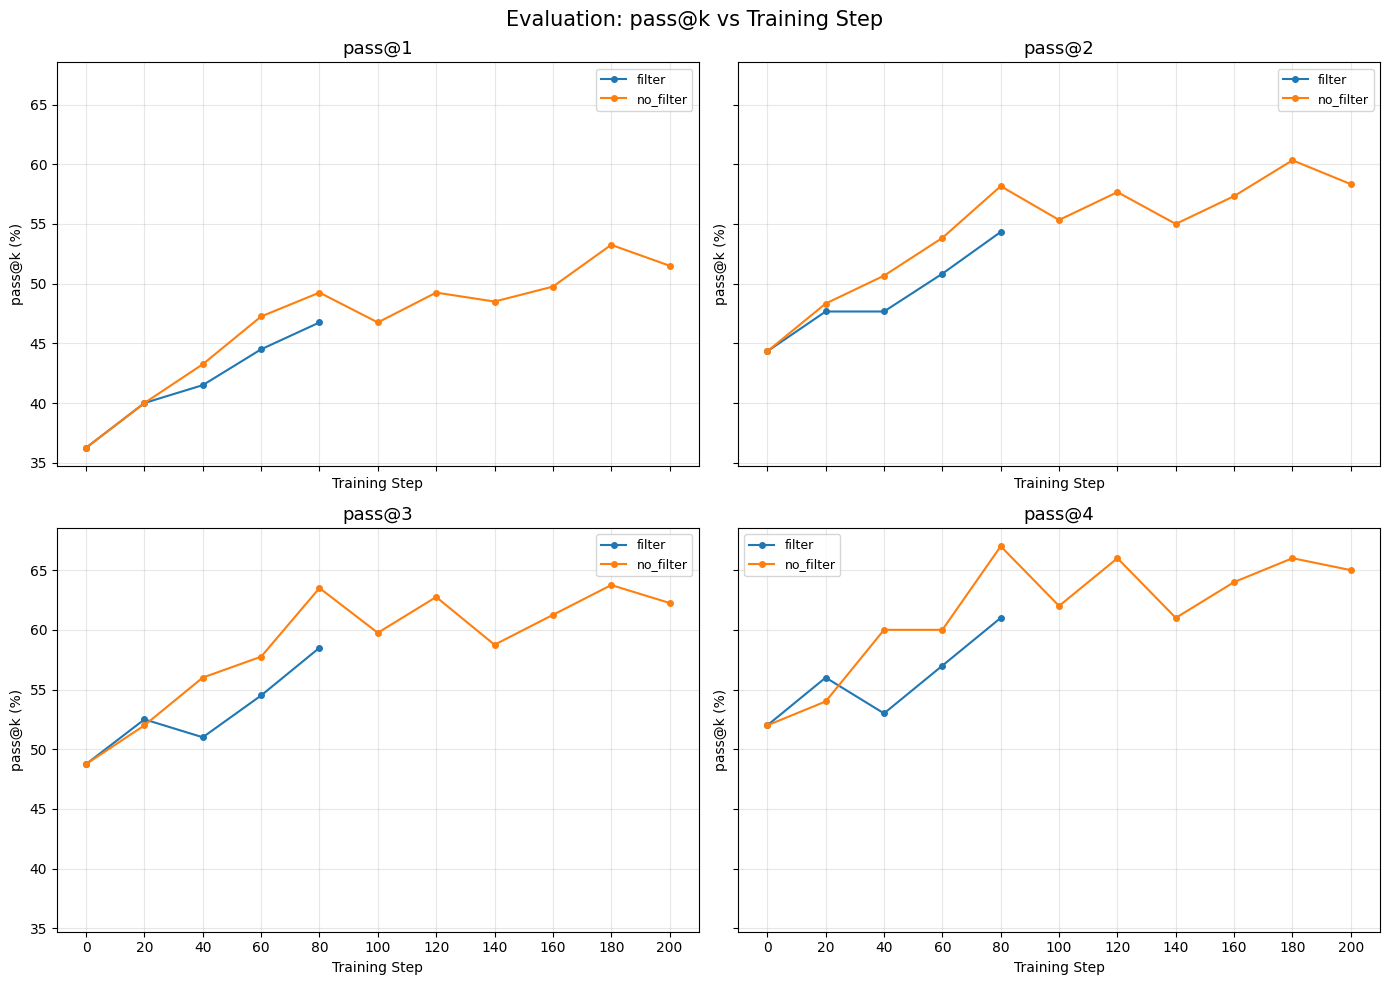

Saved to /tmp/instance_storage/eval_results/pass_at_k.png


In [8]:
# ── 4. Plot pass@1 .. pass@4 ─────────────────────────────────────────

# Friendly display names (strip common suffixes for readability)
def short_name(model: str) -> str:
    return model.replace("_hf", "").replace("batch_0_200_step_", "")


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle("Evaluation: pass@k vs Training Step", fontsize=15, y=0.98)

for idx, k in enumerate(["1", "2", "3", "4"]):
    ax = axes[idx // 2][idx % 2]
    for model, c in sorted(curves.items()):
        ax.plot(
            c["steps"],
            [v * 100 for v in c[f"pass@{k}"]],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=short_name(model),
        )
    ax.set_title(f"pass@{k}", fontsize=13)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("pass@k (%)")
    ax.set_xticks(range(0, max(max(c["steps"]) for c in curves.values()) + 1, 20))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("/tmp/instance_storage/eval_results/pass_at_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /tmp/instance_storage/eval_results/pass_at_k.png")